In [3]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

In [4]:
PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
FEATURE_DIR = DATA_DIR / "features"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

old_features_path = FEATURE_DIR / "ptb_detection_handcrafted_features_with_split.csv"
advanced_features_path = FEATURE_DIR / "ptb_detection_advanced_fiducial_features.csv"

print("Project directory:", PROJECT_DIR)
print("Old features:", old_features_path, old_features_path.exists())
print("Advanced features:", advanced_features_path, advanced_features_path.exists())

Project directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project
Old features: d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\features\ptb_detection_handcrafted_features_with_split.csv True
Advanced features: d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\features\ptb_detection_advanced_fiducial_features.csv True


In [5]:
PURPLE_MAIN = "#C599B6"
PURPLE_DARK = "#8A5A78"
PURPLE_LIGHT = "#E8D3DF"
PURPLE_MID = "#B77FA0"
RED_SOFT = "#C44E52"
GRAY = "#6B6B6B"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [6]:
old_df = pd.read_csv(old_features_path)
advanced_df = pd.read_csv(advanced_features_path)

print("Old feature table shape:", old_df.shape)
print("Advanced feature table shape:", advanced_df.shape)

display(old_df.head())
display(advanced_df.head())

print("\nOld split counts:")
display(old_df["split"].value_counts())

print("\nAdvanced extraction status:")
display(advanced_df["extraction_status"].value_counts())

Old feature table shape: (448, 1423)
Advanced feature table shape: (448, 2579)


,patient_id,record_id,record_path,mi_detected,healthy_control,reason_for_admission,extraction_status,error_message,fs,duration_sec,...,contrast_lateral_over_chest_morph_qrs_ptp_mean,contrast_lateral_minus_chest_morph_st_level_mean,contrast_lateral_over_chest_morph_st_level_mean,contrast_lateral_minus_chest_morph_t_amp_mean,contrast_lateral_over_chest_morph_t_amp_mean,contrast_lateral_minus_chest_ratio_abs_st_to_qrs,contrast_lateral_over_chest_ratio_abs_st_to_qrs,contrast_lateral_minus_chest_ratio_abs_t_to_qrs,contrast_lateral_over_chest_ratio_abs_t_to_qrs,split
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,NaN,1000,38.4,...,0.869859,-0.113679,-1.232628,-0.277465,-1.848635,0.028838,1.397076,0.076624,1.332658,train
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,0.919469,-0.071970,-1.296162,-0.036523,0.432207,0.011147,1.290027,0.047875,1.497575,train
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,0.914905,-0.191350,-1.982390,0.611210,0.365668,0.019226,1.461171,0.034442,1.445004,train
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,0.992804,-0.154674,-3.082995,0.024435,-0.989664,0.032816,3.750345,0.080275,1.202903,test
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,1.185153,-0.406936,-3.138080,-0.857880,0.563911,-0.032781,0.577757,-0.252801,0.530411,train


,patient_id,record_id,record_path,reason_for_admission,mi_detected,healthy_control,extraction_status,error_message,fs,duration_sec,...,contrast_chest_minus_limb_adv_st_level_j80_mean,contrast_inferior_minus_anterior_adv_t_amp_mean,contrast_lateral_minus_anterior_adv_t_amp_mean,contrast_chest_minus_limb_adv_t_amp_mean,contrast_inferior_minus_anterior_adv_q_amp_mean,contrast_lateral_minus_anterior_adv_q_amp_mean,contrast_chest_minus_limb_adv_q_amp_mean,contrast_inferior_minus_anterior_adv_qrs_ptp_amp_mean,contrast_lateral_minus_anterior_adv_qrs_ptp_amp_mean,contrast_chest_minus_limb_adv_qrs_ptp_amp_mean
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,Myocardial infarction,1,0,success,NaN,1000,38.4,...,-0.372797,-2.886837,-0.929231,0.238442,-2.930195,-1.388442,1.262988,-3.210493,-1.605038,1.447418
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,Myocardial infarction,1,0,success,NaN,1000,115.2,...,-0.280683,-1.682576,-0.277867,0.130424,-3.572690,-2.157368,0.329603,-2.015850,-0.843633,1.508595
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,Myocardial infarction,1,0,success,NaN,1000,115.2,...,-0.264795,-0.525104,0.696495,-0.445783,-3.347961,-1.438515,0.427154,-1.960238,-0.952725,1.337776
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,Myocardial infarction,1,0,success,NaN,1000,115.2,...,-0.327763,5.337668,0.346021,-2.703355,1.828850,1.855689,-0.718491,-0.586200,0.446828,0.586184
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,Myocardial infarction,1,0,success,NaN,1000,115.2,...,0.584071,-6.506432,-2.005458,2.654946,-1.514142,-0.551029,1.496457,-1.033743,1.852081,0.523803



Old split counts:


split
train         308
validation     72
test           68
Name: count, dtype: int64


Advanced extraction status:


extraction_status
success    448
Name: count, dtype: int64

In [7]:
split_cols = old_df[["patient_id", "record_id", "split"]].copy()

advanced_df = advanced_df.merge(
    split_cols,
    on=["patient_id", "record_id"],
    how="left"
)

print("Advanced table after merging split:", advanced_df.shape)

print("\nMissing split:")
display(advanced_df["split"].isna().value_counts())

print("\nSplit counts:")
display(advanced_df["split"].value_counts())

print("\nClass distribution by split:")
display(pd.crosstab(advanced_df["split"], advanced_df["mi_detected"]))

Advanced table after merging split: (448, 2580)

Missing split:


split
False    448
Name: count, dtype: int64


Split counts:


split
train         308
validation     72
test           68
Name: count, dtype: int64


Class distribution by split:


mi_detected,0,1
split,,
test,12,56
train,57,251
validation,11,61


In [8]:
def evaluate_binary_classifier(y_true, y_pred, y_score=None, model_name="", dataset_name=""):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    result = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_mi": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_sensitivity_mi": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "specificity_healthy": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_mi": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    if y_score is not None:
        try:
            result["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            result["roc_auc"] = np.nan
    else:
        result["roc_auc"] = np.nan

    return result


def plot_confusion_matrix_custom(cm, title, save_path=None):
    fig, ax = plt.subplots(figsize=(5.5, 5))

    im = ax.imshow(cm, cmap="PuRd")

    labels = ["Healthy Control", "MI"]

    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    max_value = cm.max()

    for i in range(2):
        for j in range(2):
            value = cm[i, j]
            text_color = "white" if value > max_value / 2 else "black"
            ax.text(
                j,
                i,
                str(value),
                ha="center",
                va="center",
                color=text_color,
                fontsize=14,
                fontweight="bold"
            )

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()

# Prepare Old and Advanced Models

In [9]:
# cell 7
old_exclude_cols = [
    "patient_id",
    "record_id",
    "record_path",
    "reason_for_admission",
    "extraction_status",
    "error_message",
    "rpeak_detection_direction",
    "mi_detected",
    "healthy_control",
    "split",
    "fs",
    "duration_sec",
    "n_samples",
    "n_channels_original",
    "n_detected_rpeaks",
    "n_valid_beats",
    "beat_length_samples",
    "rhythm_n_detected_rpeaks",
    "rhythm_duration_sec"
]

old_numeric_cols = old_df.select_dtypes(include=[np.number]).columns.tolist()

old_feature_cols = [
    col for col in old_numeric_cols
    if col not in old_exclude_cols
]

# Remove normalization-derived statistical columns as in Notebook 6
remove_stat_keywords = [
    "_stat_mean",
    "_stat_std",
    "_stat_var",
    "_stat_rms",
    "_stat_energy"
]

old_clean_feature_cols = [
    col for col in old_feature_cols
    if not any(keyword in col for keyword in remove_stat_keywords)
]

print("Old original feature columns:", len(old_feature_cols))
print("Old clean feature columns:", len(old_clean_feature_cols))
print(old_clean_feature_cols[:30])

Old original feature columns: 1404
Old clean feature columns: 1304
['rhythm_hr_count', 'rhythm_hr_mean', 'rhythm_hr_median', 'rhythm_hr_std', 'rhythm_rr_mean', 'rhythm_rr_median', 'rhythm_rr_std', 'rhythm_rr_min', 'rhythm_rr_max', 'rhythm_rr_range', 'rhythm_rmssd', 'rhythm_pnn50', 'i_stat_median', 'i_stat_min', 'i_stat_max', 'i_stat_range', 'i_stat_abs_mean', 'i_stat_iqr', 'i_stat_skewness', 'i_stat_kurtosis', 'i_stat_entropy', 'i_stat_zcr', 'ii_stat_median', 'ii_stat_min', 'ii_stat_max', 'ii_stat_range', 'ii_stat_abs_mean', 'ii_stat_iqr', 'ii_stat_skewness', 'ii_stat_kurtosis']


In [10]:
advanced_exclude_cols = [
    "patient_id",
    "record_id",
    "record_path",
    "reason_for_admission",
    "extraction_status",
    "error_message",
    "qrs_detection_direction",
    "mi_detected",
    "healthy_control",
    "split",
    "fs",
    "duration_sec",
    "n_samples",
    "n_detected_qrs_peaks",
    "n_valid_beats"
]

advanced_numeric_cols = advanced_df.select_dtypes(include=[np.number]).columns.tolist()

advanced_feature_cols = [
    col for col in advanced_numeric_cols
    if col not in advanced_exclude_cols
]

print("Advanced feature columns:", len(advanced_feature_cols))
print(advanced_feature_cols[:30])

Advanced feature columns: 2565
['rhythm_hr_median', 'rhythm_rr_std', 'i_adv_q_amp_mean', 'i_adv_q_amp_median', 'i_adv_q_amp_std', 'i_adv_q_amp_min', 'i_adv_q_amp_max', 'i_adv_q_amp_iqr', 'i_adv_s_amp_mean', 'i_adv_s_amp_median', 'i_adv_s_amp_std', 'i_adv_s_amp_min', 'i_adv_s_amp_max', 'i_adv_s_amp_iqr', 'i_adv_q_time_mean', 'i_adv_q_time_median', 'i_adv_q_time_std', 'i_adv_q_time_min', 'i_adv_q_time_max', 'i_adv_q_time_iqr', 'i_adv_s_time_mean', 'i_adv_s_time_median', 'i_adv_s_time_std', 'i_adv_s_time_min', 'i_adv_s_time_max', 'i_adv_s_time_iqr', 'i_adv_qrs_peak_amp_mean', 'i_adv_qrs_peak_amp_median', 'i_adv_qrs_peak_amp_std', 'i_adv_qrs_peak_amp_min']


In [11]:
old_train_df = old_df[old_df["split"] == "train"].copy()
old_val_df = old_df[old_df["split"] == "validation"].copy()
old_test_df = old_df[old_df["split"] == "test"].copy()

adv_train_df = advanced_df[advanced_df["split"] == "train"].copy()
adv_val_df = advanced_df[advanced_df["split"] == "validation"].copy()
adv_test_df = advanced_df[advanced_df["split"] == "test"].copy()

print("Old train/val/test:", old_train_df.shape, old_val_df.shape, old_test_df.shape)
print("Advanced train/val/test:", adv_train_df.shape, adv_val_df.shape, adv_test_df.shape)

print("\nClass distribution:")
display(pd.crosstab(old_df["split"], old_df["mi_detected"]))

print("\nPatient leakage check:")
for name_a, df_a in [("train", old_train_df), ("validation", old_val_df), ("test", old_test_df)]:
    for name_b, df_b in [("train", old_train_df), ("validation", old_val_df), ("test", old_test_df)]:
        if name_a < name_b:
            overlap = set(df_a["patient_id"]) & set(df_b["patient_id"])
            print(f"{name_a} ∩ {name_b}: {len(overlap)}")

Old train/val/test: (308, 1423) (72, 1423) (68, 1423)
Advanced train/val/test: (308, 2580) (72, 2580) (68, 2580)

Class distribution:


mi_detected,0,1
split,,
test,12,56
train,57,251
validation,11,61



Patient leakage check:
train ∩ validation: 0
test ∩ train: 0
test ∩ validation: 0


In [12]:
# Old SVM RBF baseline from Notebook 6
old_svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=200)),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

# Advanced Extra Trees from Notebook 6B
advanced_extra_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=50)),
    ("model", ExtraTreesClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Fit old SVM
X_old_train = old_train_df[old_clean_feature_cols].astype("float32")
y_old_train = old_train_df["mi_detected"]

X_old_val = old_val_df[old_clean_feature_cols].astype("float32")
y_old_val = old_val_df["mi_detected"]

X_old_test = old_test_df[old_clean_feature_cols].astype("float32")
y_old_test = old_test_df["mi_detected"]

old_svm_pipe.fit(X_old_train, y_old_train)

# Fit advanced Extra Trees
X_adv_train = adv_train_df[advanced_feature_cols].astype("float32")
y_adv_train = adv_train_df["mi_detected"]

X_adv_val = adv_val_df[advanced_feature_cols].astype("float32")
y_adv_val = adv_val_df["mi_detected"]

X_adv_test = adv_test_df[advanced_feature_cols].astype("float32")
y_adv_test = adv_test_df["mi_detected"]

advanced_extra_pipe.fit(X_adv_train, y_adv_train)

print("Old SVM and Advanced Extra Trees fitted.")

Old SVM and Advanced Extra Trees fitted.


In [13]:
# Old SVM scores
old_val_score = old_svm_pipe.predict_proba(X_old_val)[:, 1]
old_test_score = old_svm_pipe.predict_proba(X_old_test)[:, 1]

old_val_pred = (old_val_score >= 0.5).astype(int)
old_test_pred = (old_test_score >= 0.5).astype(int)

# Advanced Extra Trees scores
adv_val_score = advanced_extra_pipe.predict_proba(X_adv_val)[:, 1]
adv_test_score = advanced_extra_pipe.predict_proba(X_adv_test)[:, 1]

adv_val_pred = (adv_val_score >= 0.5).astype(int)
adv_test_pred = (adv_test_score >= 0.5).astype(int)

old_test_result = evaluate_binary_classifier(
    y_old_test,
    old_test_pred,
    y_score=old_test_score,
    model_name="Old SVM RBF",
    dataset_name="test"
)

adv_test_result = evaluate_binary_classifier(
    y_adv_test,
    adv_test_pred,
    y_score=adv_test_score,
    model_name="Advanced Extra Trees",
    dataset_name="test"
)

print("Old SVM test result:")
display(pd.DataFrame([old_test_result]))

print("Advanced Extra Trees test result:")
display(pd.DataFrame([adv_test_result]))

Old SVM test result:


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc
0,test,Old SVM RBF,0.882353,0.944444,0.910714,0.75,0.927273,0.80979,0.830357,9,3,5,51,0.9375


Advanced Extra Trees test result:


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc
0,test,Advanced Extra Trees,0.897059,0.962264,0.910714,0.833333,0.93578,0.83826,0.872024,10,2,5,51,0.929315


In [14]:
thresholds = np.linspace(0.05, 0.95, 181)

threshold_results = []

for threshold in thresholds:
    y_val_pred_threshold = (adv_val_score >= threshold).astype(int)

    result = evaluate_binary_classifier(
        y_adv_val,
        y_val_pred_threshold,
        y_score=adv_val_score,
        model_name="Advanced Extra Trees",
        dataset_name="validation"
    )

    result["threshold"] = threshold

    threshold_results.append(result)

threshold_results_df = pd.DataFrame(threshold_results)

display(
    threshold_results_df.sort_values(
        ["macro_f1", "balanced_accuracy", "recall_sensitivity_mi"],
        ascending=False
    ).head(10)
)

# Strategy 1: best macro-F1
best_macro_row = threshold_results_df.sort_values(
    ["macro_f1", "balanced_accuracy", "recall_sensitivity_mi"],
    ascending=False
).iloc[0]

# Strategy 2: recall priority with specificity >= 0.75
candidate_recall_priority = threshold_results_df[
    threshold_results_df["specificity_healthy"] >= 0.75
].copy()

if len(candidate_recall_priority) > 0:
    best_recall_priority_row = candidate_recall_priority.sort_values(
        ["recall_sensitivity_mi", "macro_f1", "balanced_accuracy"],
        ascending=False
    ).iloc[0]
else:
    best_recall_priority_row = best_macro_row

print("Best macro-F1 threshold:")
display(best_macro_row)

print("Recall-priority threshold with specificity >= 0.75:")
display(best_recall_priority_row)

,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,threshold
85,validation,Advanced Extra Trees,0.916667,0.95082,0.95082,0.727273,0.95082,0.839046,0.839046,8,3,3,58,0.916542,0.475
86,validation,Advanced Extra Trees,0.916667,0.95082,0.95082,0.727273,0.95082,0.839046,0.839046,8,3,3,58,0.916542,0.480
87,validation,Advanced Extra Trees,0.916667,0.95082,0.95082,0.727273,0.95082,0.839046,0.839046,8,3,3,58,0.916542,0.485
88,validation,Advanced Extra Trees,0.916667,0.95082,0.95082,0.727273,0.95082,0.839046,0.839046,8,3,3,58,0.916542,0.490
89,validation,Advanced Extra Trees,0.916667,0.95082,0.95082,0.727273,0.95082,0.839046,0.839046,8,3,3,58,0.916542,0.495
90,validation,Advanced Extra Trees,0.916667,0.95082,0.95082,0.727273,0.95082,0.839046,0.839046,8,3,3,58,0.916542,0.500
91,validation,Advanced Extra Trees,0.916667,0.95082,0.95082,0.727273,0.95082,0.839046,0.839046,8,3,3,58,0.916542,0.505
92,validation,Advanced Extra Trees,0.916667,0.95082,0.95082,0.727273,0.95082,0.839046,0.839046,8,3,3,58,0.916542,0.510
93,validation,Advanced Extra Trees,0.916667,0.95082,0.95082,0.727273,0.95082,0.839046,0.839046,8,3,3,58,0.916542,0.515
94,validation,Advanced Extra Trees,0.916667,0.95082,0.95082,0.727273,0.95082,0.839046,0.839046,8,3,3,58,0.916542,0.520


Best macro-F1 threshold:


dataset                            validation
model                    Advanced Extra Trees
accuracy                             0.916667
precision_mi                          0.95082
recall_sensitivity_mi                 0.95082
specificity_healthy                  0.727273
f1_mi                                 0.95082
macro_f1                             0.839046
balanced_accuracy                    0.839046
tn                                          8
fp                                          3
fn                                          3
tp                                         58
roc_auc                              0.916542
threshold                               0.475
Name: 85, dtype: object

Recall-priority threshold with specificity >= 0.75:


dataset                            validation
model                    Advanced Extra Trees
accuracy                             0.888889
precision_mi                         0.964912
recall_sensitivity_mi                0.901639
specificity_healthy                  0.818182
f1_mi                                0.932203
macro_f1                             0.812256
balanced_accuracy                    0.859911
tn                                          9
fp                                          2
fn                                          6
tp                                         55
roc_auc                              0.916542
threshold                               0.625
Name: 115, dtype: object

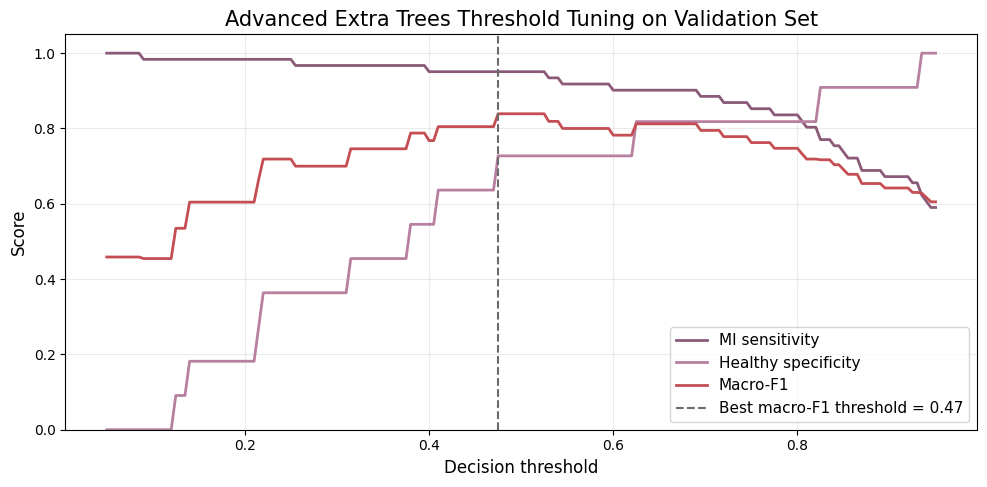

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6C_advanced_threshold_tuning.png


In [15]:
# Cell 13
plt.figure(figsize=(10, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall_sensitivity_mi"],
    label="MI sensitivity",
    color=PURPLE_DARK,
    linewidth=2
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["specificity_healthy"],
    label="Healthy specificity",
    color=PURPLE_MID,
    linewidth=2
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["macro_f1"],
    label="Macro-F1",
    color=RED_SOFT,
    linewidth=2
)

plt.axvline(
    best_macro_row["threshold"],
    color=GRAY,
    linestyle="--",
    label=f"Best macro-F1 threshold = {best_macro_row['threshold']:.2f}"
)

plt.title("Advanced Extra Trees Threshold Tuning on Validation Set")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

fig_path = FIGURE_DIR / "notebook6C_advanced_threshold_tuning.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [16]:
threshold_test_results = []

threshold_settings = [
    ("default_0.50", 0.50),
    ("best_macro_f1_threshold", float(best_macro_row["threshold"])),
    ("recall_priority_threshold", float(best_recall_priority_row["threshold"]))
]

for setting_name, threshold in threshold_settings:
    y_test_pred_threshold = (adv_test_score >= threshold).astype(int)

    result = evaluate_binary_classifier(
        y_adv_test,
        y_test_pred_threshold,
        y_score=adv_test_score,
        model_name="Advanced Extra Trees",
        dataset_name="test"
    )

    result["setting"] = setting_name
    result["threshold"] = threshold

    threshold_test_results.append(result)

threshold_test_results_df = pd.DataFrame(threshold_test_results)

display(threshold_test_results_df)

threshold_test_path = TABLE_DIR / "notebook6C_advanced_threshold_test_results.csv"
threshold_test_results_df.to_csv(
    threshold_test_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", threshold_test_path)

,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,setting,threshold
0,test,Advanced Extra Trees,0.897059,0.962264,0.910714,0.833333,0.935780,0.838260,0.872024,10,2,5,51,0.929315,default_0.50,0.500
1,test,Advanced Extra Trees,0.897059,0.962264,0.910714,0.833333,0.935780,0.838260,0.872024,10,2,5,51,0.929315,best_macro_f1_threshold,0.475
2,test,Advanced Extra Trees,0.867647,0.960784,0.875000,0.833333,0.915888,0.802772,0.854167,10,2,7,49,0.929315,recall_priority_threshold,0.625


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6C_advanced_threshold_test_results.csv


# Experiment 2 — Ensemble Old SVM + Advanced Extra Trees

In [18]:
# Cell 15
ensemble_results = []

weights_old = np.linspace(0.0, 1.0, 21)

for w_old in weights_old:
    w_adv = 1.0 - w_old

    ensemble_val_score = w_old * old_val_score + w_adv * adv_val_score
    ensemble_val_pred = (ensemble_val_score >= 0.5).astype(int)

    result = evaluate_binary_classifier(
        y_old_val,
        ensemble_val_pred,
        y_score=ensemble_val_score,
        model_name="Old SVM + Advanced Extra Trees",
        dataset_name="validation"
    )

    result["w_old_svm"] = w_old
    result["w_advanced_extra"] = w_adv

    ensemble_results.append(result)

ensemble_results_df = pd.DataFrame(ensemble_results)

display(
    ensemble_results_df.sort_values(
        ["macro_f1", "balanced_accuracy", "recall_sensitivity_mi"],
        ascending=False
    )
)

best_ensemble_row = ensemble_results_df.sort_values(
    ["macro_f1", "balanced_accuracy", "recall_sensitivity_mi"],
    ascending=False
).iloc[0]

print("Best ensemble setting on validation:")
display(best_ensemble_row)

,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,w_old_svm,w_advanced_extra
0,validation,Old SVM + Advanced Extra Trees,0.916667,0.950820,0.950820,0.727273,0.950820,0.839046,0.839046,8,3,3,58,0.916542,0.00,1.00
1,validation,Old SVM + Advanced Extra Trees,0.916667,0.950820,0.950820,0.727273,0.950820,0.839046,0.839046,8,3,3,58,0.923994,0.05,0.95
2,validation,Old SVM + Advanced Extra Trees,0.902778,0.935484,0.950820,0.636364,0.943089,0.804878,0.793592,7,4,3,58,0.928465,0.10,0.90
3,validation,Old SVM + Advanced Extra Trees,0.902778,0.935484,0.950820,0.636364,0.943089,0.804878,0.793592,7,4,3,58,0.935917,0.15,0.85
8,validation,Old SVM + Advanced Extra Trees,0.888889,0.934426,0.934426,0.636364,0.934426,0.785395,0.785395,7,4,4,57,0.949329,0.40,0.60
9,validation,Old SVM + Advanced Extra Trees,0.888889,0.934426,0.934426,0.636364,0.934426,0.785395,0.785395,7,4,4,57,0.947839,0.45,0.55
10,validation,Old SVM + Advanced Extra Trees,0.888889,0.934426,0.934426,0.636364,0.934426,0.785395,0.785395,7,4,4,57,0.949329,0.50,0.50
11,validation,Old SVM + Advanced Extra Trees,0.888889,0.934426,0.934426,0.636364,0.934426,0.785395,0.785395,7,4,4,57,0.949329,0.55,0.45
4,validation,Old SVM + Advanced Extra Trees,0.888889,0.920635,0.950820,0.545455,0.935484,0.767742,0.748137,6,5,3,58,0.941878,0.20,0.80
5,validation,Old SVM + Advanced Extra Trees,0.888889,0.920635,0.950820,0.545455,0.935484,0.767742,0.748137,6,5,3,58,0.944858,0.25,0.75


Best ensemble setting on validation:


dataset                                      validation
model                    Old SVM + Advanced Extra Trees
accuracy                                       0.916667
precision_mi                                    0.95082
recall_sensitivity_mi                           0.95082
specificity_healthy                            0.727273
f1_mi                                           0.95082
macro_f1                                       0.839046
balanced_accuracy                              0.839046
tn                                                    8
fp                                                    3
fn                                                    3
tp                                                   58
roc_auc                                        0.916542
w_old_svm                                           0.0
w_advanced_extra                                    1.0
Name: 0, dtype: object

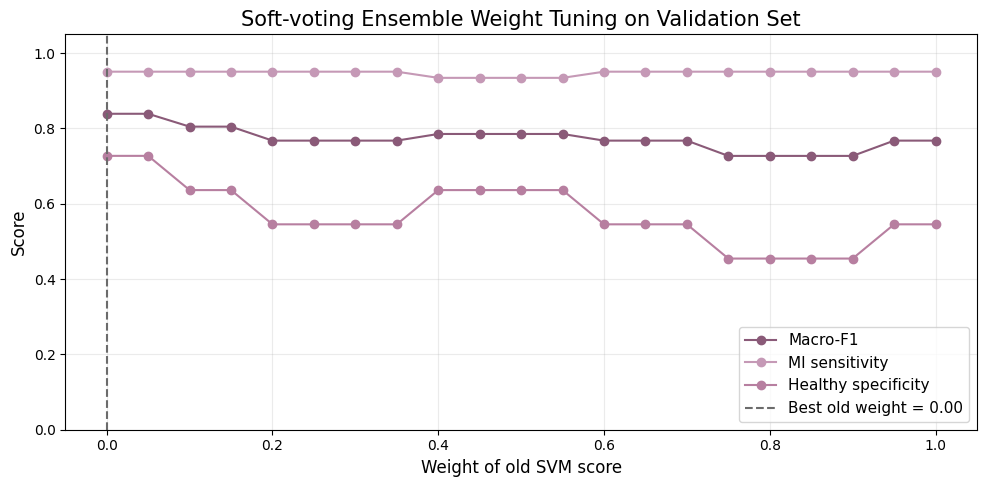

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6C_ensemble_weight_tuning.png


In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    ensemble_results_df["w_old_svm"],
    ensemble_results_df["macro_f1"],
    marker="o",
    label="Macro-F1",
    color=PURPLE_DARK
)

plt.plot(
    ensemble_results_df["w_old_svm"],
    ensemble_results_df["recall_sensitivity_mi"],
    marker="o",
    label="MI sensitivity",
    color=PURPLE_MAIN
)

plt.plot(
    ensemble_results_df["w_old_svm"],
    ensemble_results_df["specificity_healthy"],
    marker="o",
    label="Healthy specificity",
    color=PURPLE_MID
)

plt.axvline(
    best_ensemble_row["w_old_svm"],
    color=GRAY,
    linestyle="--",
    label=f"Best old weight = {best_ensemble_row['w_old_svm']:.2f}"
)

plt.title("Soft-voting Ensemble Weight Tuning on Validation Set")
plt.xlabel("Weight of old SVM score")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

fig_path = FIGURE_DIR / "notebook6C_ensemble_weight_tuning.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

Best ensemble test result:


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,w_old_svm,w_advanced_extra
0,test,Soft Ensemble,0.897059,0.962264,0.910714,0.833333,0.93578,0.83826,0.872024,10,2,5,51,0.929315,0.0,1.0



Classification report:
                 precision    recall  f1-score   support

Healthy Control       0.67      0.83      0.74        12
             MI       0.96      0.91      0.94        56

       accuracy                           0.90        68
      macro avg       0.81      0.87      0.84        68
   weighted avg       0.91      0.90      0.90        68



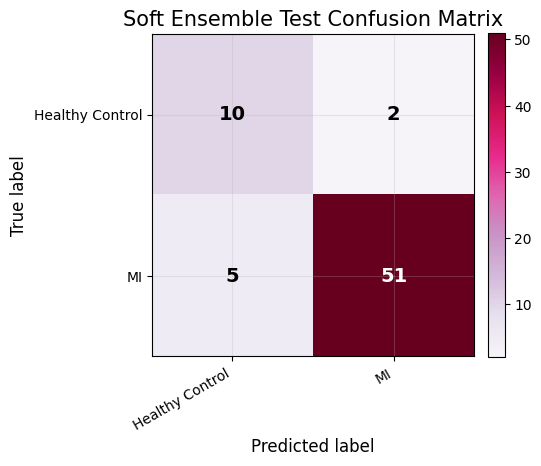

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6C_ensemble_test_confusion_matrix.png


In [20]:
best_w_old = float(best_ensemble_row["w_old_svm"])
best_w_adv = float(best_ensemble_row["w_advanced_extra"])

ensemble_test_score = best_w_old * old_test_score + best_w_adv * adv_test_score
ensemble_test_pred = (ensemble_test_score >= 0.5).astype(int)

ensemble_test_result = evaluate_binary_classifier(
    y_old_test,
    ensemble_test_pred,
    y_score=ensemble_test_score,
    model_name="Soft Ensemble",
    dataset_name="test"
)

ensemble_test_result["w_old_svm"] = best_w_old
ensemble_test_result["w_advanced_extra"] = best_w_adv

ensemble_test_result_df = pd.DataFrame([ensemble_test_result])

print("Best ensemble test result:")
display(ensemble_test_result_df)

print("\nClassification report:")
print(
    classification_report(
        y_old_test,
        ensemble_test_pred,
        target_names=["Healthy Control", "MI"],
        zero_division=0
    )
)

cm_ensemble = confusion_matrix(y_old_test, ensemble_test_pred, labels=[0, 1])

fig_path = FIGURE_DIR / "notebook6C_ensemble_test_confusion_matrix.png"

plot_confusion_matrix_custom(
    cm_ensemble,
    title="Soft Ensemble Test Confusion Matrix",
    save_path=fig_path
)

print("Saved:", fig_path)

# Experiment 3 — Record-wise Split Comparison

In [21]:
recordwise_df = advanced_df.copy()

# Remove rows without valid extraction just in case
recordwise_df = recordwise_df[recordwise_df["extraction_status"] == "success"].copy()

X_recordwise = recordwise_df[advanced_feature_cols].astype("float32")
y_recordwise = recordwise_df["mi_detected"].astype(int)

# First split train_temp/test
X_rw_train_temp, X_rw_test, y_rw_train_temp, y_rw_test = train_test_split(
    X_recordwise,
    y_recordwise,
    test_size=0.15,
    random_state=42,
    stratify=y_recordwise
)

# Then split train/validation
X_rw_train, X_rw_val, y_rw_train, y_rw_val = train_test_split(
    X_rw_train_temp,
    y_rw_train_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_rw_train_temp
)

print("Record-wise train shape:", X_rw_train.shape)
print("Record-wise validation shape:", X_rw_val.shape)
print("Record-wise test shape:", X_rw_test.shape)

print("\nClass distributions:")
print("Train:")
display(y_rw_train.value_counts())
print("Validation:")
display(y_rw_val.value_counts())
print("Test:")
display(y_rw_test.value_counts())

Record-wise train shape: (312, 2565)
Record-wise validation shape: (68, 2565)
Record-wise test shape: (68, 2565)

Class distributions:
Train:


mi_detected
1    256
0     56
Name: count, dtype: int64

Validation:


mi_detected
1    56
0    12
Name: count, dtype: int64

Test:


mi_detected
1    56
0    12
Name: count, dtype: int64

In [22]:
recordwise_extra_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=50)),
    ("model", ExtraTreesClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

recordwise_extra_pipe.fit(X_rw_train, y_rw_train)

rw_val_score = recordwise_extra_pipe.predict_proba(X_rw_val)[:, 1]
rw_val_pred = (rw_val_score >= 0.5).astype(int)

rw_test_score = recordwise_extra_pipe.predict_proba(X_rw_test)[:, 1]
rw_test_pred = (rw_test_score >= 0.5).astype(int)

rw_val_result = evaluate_binary_classifier(
    y_rw_val,
    rw_val_pred,
    y_score=rw_val_score,
    model_name="Advanced Extra Trees",
    dataset_name="recordwise_validation"
)

rw_test_result = evaluate_binary_classifier(
    y_rw_test,
    rw_test_pred,
    y_score=rw_test_score,
    model_name="Advanced Extra Trees",
    dataset_name="recordwise_test"
)

print("Record-wise validation result:")
display(pd.DataFrame([rw_val_result]))

print("Record-wise test result:")
display(pd.DataFrame([rw_test_result]))

print("\nRecord-wise test classification report:")
print(
    classification_report(
        y_rw_test,
        rw_test_pred,
        target_names=["Healthy Control", "MI"],
        zero_division=0
    )
)

Record-wise validation result:


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc
0,recordwise_validation,Advanced Extra Trees,0.897059,0.945455,0.928571,0.75,0.936937,0.828468,0.839286,9,3,4,52,0.955357


Record-wise test result:


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc
0,recordwise_test,Advanced Extra Trees,0.911765,0.931034,0.964286,0.666667,0.947368,0.837321,0.815476,8,4,2,54,0.950893



Record-wise test classification report:
                 precision    recall  f1-score   support

Healthy Control       0.80      0.67      0.73        12
             MI       0.93      0.96      0.95        56

       accuracy                           0.91        68
      macro avg       0.87      0.82      0.84        68
   weighted avg       0.91      0.91      0.91        68



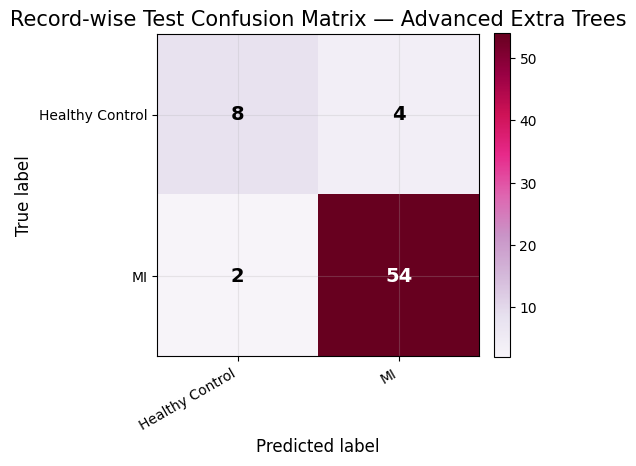

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6C_recordwise_test_confusion_matrix.png


In [23]:
cm_rw = confusion_matrix(y_rw_test, rw_test_pred, labels=[0, 1])

fig_path = FIGURE_DIR / "notebook6C_recordwise_test_confusion_matrix.png"

plot_confusion_matrix_custom(
    cm_rw,
    title="Record-wise Test Confusion Matrix — Advanced Extra Trees",
    save_path=fig_path
)

print("Saved:", fig_path)

In [24]:
summary_rows = []

# Old SVM default
old_row = old_test_result.copy()
old_row["setting"] = "Patient-wise old SVM baseline"
summary_rows.append(old_row)

# Advanced Extra Trees default
adv_row = adv_test_result.copy()
adv_row["setting"] = "Patient-wise advanced Extra Trees default"
summary_rows.append(adv_row)

# Best threshold
best_threshold_test_row = threshold_test_results_df.sort_values(
    ["macro_f1", "balanced_accuracy", "recall_sensitivity_mi"],
    ascending=False
).iloc[0].to_dict()

best_threshold_test_row["setting"] = "Patient-wise advanced Extra Trees tuned threshold"
summary_rows.append(best_threshold_test_row)

# Ensemble
ensemble_row = ensemble_test_result.copy()
ensemble_row["setting"] = "Patient-wise old + advanced soft ensemble"
summary_rows.append(ensemble_row)

# Record-wise
rw_row = rw_test_result.copy()
rw_row["setting"] = "Record-wise advanced Extra Trees"
summary_rows.append(rw_row)

enhancement_summary_df = pd.DataFrame(summary_rows)

selected_cols = [
    "setting",
    "dataset",
    "model",
    "accuracy",
    "precision_mi",
    "recall_sensitivity_mi",
    "specificity_healthy",
    "f1_mi",
    "macro_f1",
    "balanced_accuracy",
    "roc_auc",
    "tn",
    "fp",
    "fn",
    "tp"
]

enhancement_summary_df = enhancement_summary_df[selected_cols]

display(enhancement_summary_df)

summary_path = TABLE_DIR / "notebook6C_performance_enhancement_summary.csv"
enhancement_summary_df.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", summary_path)

,setting,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp
0,Patient-wise old SVM baseline,test,Old SVM RBF,0.882353,0.944444,0.910714,0.750000,0.927273,0.809790,0.830357,0.937500,9,3,5,51
1,Patient-wise advanced Extra Trees default,test,Advanced Extra Trees,0.897059,0.962264,0.910714,0.833333,0.935780,0.838260,0.872024,0.929315,10,2,5,51
2,Patient-wise advanced Extra Trees tuned threshold,test,Advanced Extra Trees,0.897059,0.962264,0.910714,0.833333,0.935780,0.838260,0.872024,0.929315,10,2,5,51
3,Patient-wise old + advanced soft ensemble,test,Soft Ensemble,0.897059,0.962264,0.910714,0.833333,0.935780,0.838260,0.872024,0.929315,10,2,5,51
4,Record-wise advanced Extra Trees,recordwise_test,Advanced Extra Trees,0.911765,0.931034,0.964286,0.666667,0.947368,0.837321,0.815476,0.950893,8,4,2,54


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6C_performance_enhancement_summary.csv


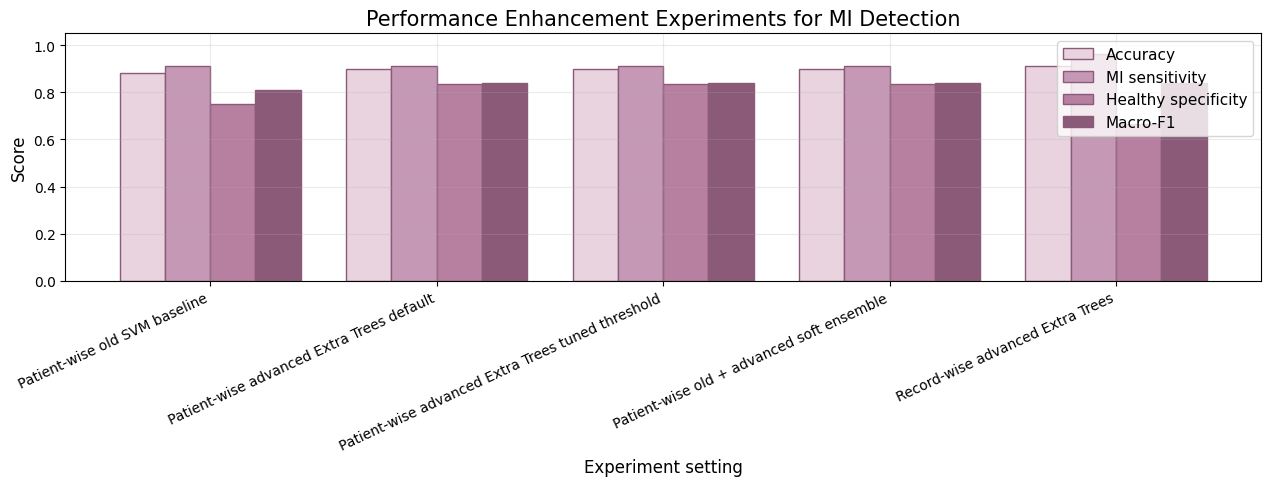

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6C_performance_enhancement_comparison.png


In [25]:
plot_df = enhancement_summary_df.copy()

x = np.arange(len(plot_df))
width = 0.2

plt.figure(figsize=(13, 5))

plt.bar(
    x - 1.5 * width,
    plot_df["accuracy"],
    width,
    label="Accuracy",
    color=PURPLE_LIGHT,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x - 0.5 * width,
    plot_df["recall_sensitivity_mi"],
    width,
    label="MI sensitivity",
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + 0.5 * width,
    plot_df["specificity_healthy"],
    width,
    label="Healthy specificity",
    color=PURPLE_MID,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + 1.5 * width,
    plot_df["macro_f1"],
    width,
    label="Macro-F1",
    color=PURPLE_DARK,
    edgecolor=PURPLE_DARK
)

plt.title("Performance Enhancement Experiments for MI Detection")
plt.xlabel("Experiment setting")
plt.ylabel("Score")
plt.xticks(x, plot_df["setting"], rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

fig_path = FIGURE_DIR / "notebook6C_performance_enhancement_comparison.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [26]:
reference_comparison_df = pd.DataFrame([
    {
        "study": "Paper 1",
        "method": "Morphological features + Random Forest",
        "evaluation_note": "Reported result",
        "lead_setting": "12 leads",
        "accuracy": 0.9654,
        "sensitivity": 0.9974,
        "specificity": 0.8358,
        "f1_or_macro_f1": 0.9788
    },
    {
        "study": "Paper 2",
        "method": "GA-LSLO + CNN + Lead Attention",
        "evaluation_note": "Reported result",
        "lead_setting": "Optimized 6 leads",
        "accuracy": 0.9762,
        "sensitivity": 0.9601,
        "specificity": 0.9601,
        "f1_or_macro_f1": 0.9625
    },
    {
        "study": "Our main patient-wise result",
        "method": "Advanced fiducial-inspired features + Extra Trees",
        "evaluation_note": "Strict patient-wise split",
        "lead_setting": "12 leads",
        "accuracy": float(adv_test_result["accuracy"]),
        "sensitivity": float(adv_test_result["recall_sensitivity_mi"]),
        "specificity": float(adv_test_result["specificity_healthy"]),
        "f1_or_macro_f1": float(adv_test_result["macro_f1"])
    },
    {
        "study": "Our record-wise comparison",
        "method": "Advanced fiducial-inspired features + Extra Trees",
        "evaluation_note": "Record-wise split, less strict",
        "lead_setting": "12 leads",
        "accuracy": float(rw_test_result["accuracy"]),
        "sensitivity": float(rw_test_result["recall_sensitivity_mi"]),
        "specificity": float(rw_test_result["specificity_healthy"]),
        "f1_or_macro_f1": float(rw_test_result["macro_f1"])
    }
])

display(reference_comparison_df)

reference_comparison_path = TABLE_DIR / "notebook6C_reference_comparison.csv"
reference_comparison_df.to_csv(
    reference_comparison_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", reference_comparison_path)

,study,method,evaluation_note,lead_setting,accuracy,sensitivity,specificity,f1_or_macro_f1
0,Paper 1,Morphological features + Random Forest,Reported result,12 leads,0.965400,0.997400,0.835800,0.978800
1,Paper 2,GA-LSLO + CNN + Lead Attention,Reported result,Optimized 6 leads,0.976200,0.960100,0.960100,0.962500
2,Our main patient-wise result,Advanced fiducial-inspired features + Extra Trees,Strict patient-wise split,12 leads,0.897059,0.910714,0.833333,0.838260
3,Our record-wise comparison,Advanced fiducial-inspired features + Extra Trees,"Record-wise split, less strict",12 leads,0.911765,0.964286,0.666667,0.837321


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6C_reference_comparison.csv


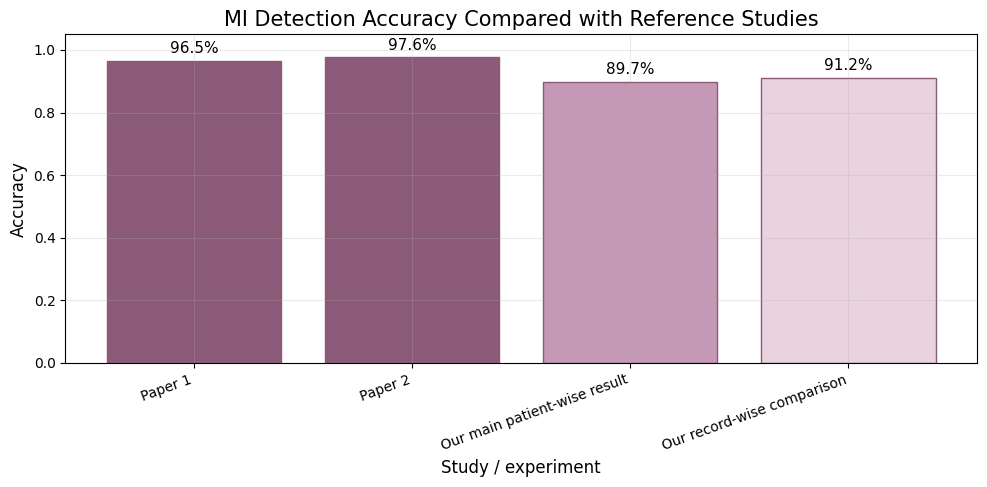

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6C_reference_accuracy_comparison.png


In [27]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    reference_comparison_df["study"],
    reference_comparison_df["accuracy"],
    color=[PURPLE_DARK, PURPLE_DARK, PURPLE_MAIN, PURPLE_LIGHT],
    edgecolor=PURPLE_DARK
)

plt.title("MI Detection Accuracy Compared with Reference Studies")
plt.xlabel("Study / experiment")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height * 100:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

fig_path = FIGURE_DIR / "notebook6C_reference_accuracy_comparison.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [28]:
notebook6C_summary = {
    "notebook": "06C_performance_enhancement_experiments",
    "task": "Binary MI detection",
    "experiments": [
        "Threshold tuning for advanced Extra Trees",
        "Soft-voting ensemble between old SVM and advanced Extra Trees",
        "Record-wise split comparison"
    ],
    "main_result_note": (
        "Patient-wise split remains the main evaluation protocol. "
        "Record-wise split is used only as a protocol comparison with reference papers."
    ),
    "old_svm_test": {
        "accuracy": float(old_test_result["accuracy"]),
        "sensitivity": float(old_test_result["recall_sensitivity_mi"]),
        "specificity": float(old_test_result["specificity_healthy"]),
        "macro_f1": float(old_test_result["macro_f1"]),
        "roc_auc": float(old_test_result["roc_auc"])
    },
    "advanced_extra_trees_test": {
        "accuracy": float(adv_test_result["accuracy"]),
        "sensitivity": float(adv_test_result["recall_sensitivity_mi"]),
        "specificity": float(adv_test_result["specificity_healthy"]),
        "macro_f1": float(adv_test_result["macro_f1"]),
        "roc_auc": float(adv_test_result["roc_auc"])
    },
    "best_threshold_test": {
        "setting": str(best_threshold_test_row["setting"]),
        "accuracy": float(best_threshold_test_row["accuracy"]),
        "sensitivity": float(best_threshold_test_row["recall_sensitivity_mi"]),
        "specificity": float(best_threshold_test_row["specificity_healthy"]),
        "macro_f1": float(best_threshold_test_row["macro_f1"]),
        "roc_auc": float(best_threshold_test_row["roc_auc"])
    },
    "ensemble_test": {
        "w_old_svm": float(best_w_old),
        "w_advanced_extra": float(best_w_adv),
        "accuracy": float(ensemble_test_result["accuracy"]),
        "sensitivity": float(ensemble_test_result["recall_sensitivity_mi"]),
        "specificity": float(ensemble_test_result["specificity_healthy"]),
        "macro_f1": float(ensemble_test_result["macro_f1"]),
        "roc_auc": float(ensemble_test_result["roc_auc"])
    },
    "recordwise_test": {
        "accuracy": float(rw_test_result["accuracy"]),
        "sensitivity": float(rw_test_result["recall_sensitivity_mi"]),
        "specificity": float(rw_test_result["specificity_healthy"]),
        "macro_f1": float(rw_test_result["macro_f1"]),
        "roc_auc": float(rw_test_result["roc_auc"])
    }
}

summary_json_path = TABLE_DIR / "notebook6C_summary.json"

with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(notebook6C_summary, f, indent=4)

print(json.dumps(notebook6C_summary, indent=4))
print("Saved:", summary_json_path)

{
    "notebook": "06C_performance_enhancement_experiments",
    "task": "Binary MI detection",
    "experiments": [
        "Threshold tuning for advanced Extra Trees",
        "Soft-voting ensemble between old SVM and advanced Extra Trees",
        "Record-wise split comparison"
    ],
    "main_result_note": "Patient-wise split remains the main evaluation protocol. Record-wise split is used only as a protocol comparison with reference papers.",
    "old_svm_test": {
        "accuracy": 0.8823529411764706,
        "sensitivity": 0.9107142857142857,
        "specificity": 0.75,
        "macro_f1": 0.8097902097902098,
        "roc_auc": 0.9375
    },
    "advanced_extra_trees_test": {
        "accuracy": 0.8970588235294118,
        "sensitivity": 0.9107142857142857,
        "specificity": 0.8333333333333334,
        "macro_f1": 0.838260278627251,
        "roc_auc": 0.9293154761904762
    },
    "best_threshold_test": {
        "setting": "Patient-wise advanced Extra Trees tuned thresho